# LangGraph Agent
## Without tools

## Library Imports

In [7]:
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
import logging
from IPython.display import Image, display, Markdown
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

## Configure Logging

In [8]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename='langgraph_notebook.log',
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

## Configure Agent and Model

In [9]:
model = ChatAnthropic(model="claude-sonnet-4-5-20250929", temperature=0)

def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)

workflow.add_edge(START, "agent")

checkpointer = MemorySaver()

app = workflow.compile(checkpointer=checkpointer)

## Visualize the Graph

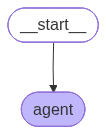

In [10]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Chat with the Agent

In [11]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What teams did Joe Montana play for?")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))

Joe Montana played for two teams during his NFL career:

1. **San Francisco 49ers** (1979-1992) - where he won four Super Bowl championships and became a legend
2. **Kansas City Chiefs** (1993-1994) - where he finished his career

He is most famous for his time with the 49ers, where he won Super Bowls XVI, XIX, XXIII, and XXIV.

In [12]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What are the leagues in the SportsWorldCentral fantasy football platform?")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))

I don't have any information about SportsWorldCentral or its fantasy football leagues. This appears to be a specific fantasy football platform that I'm not familiar with.

If you're looking for information about leagues on SportsWorldCentral, I'd recommend:
- Checking their official website
- Looking at their help/FAQ section
- Contacting their customer support
- Checking any documentation or guides they provide for users

Is there something specific about fantasy football leagues in general that I could help you with instead?